# Section 5 — Results Tables & Figures
Produces:
- **Table 4** — DiD: Extensive Margin (saw_doctor)
- **Table 5** — DiD: Intensive Margin (dv12), Panels A & B
- **Figure 7** — 2×2 DiD Decomposition
- **Table 6** — Robustness Checks Summary (Panels A & B)
- **Figure 8** — Robustness Forest Plot
- **Table 7** — Descriptive Cross-Sections

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

DATA = Path('/Users/tanishagauns/Desktop/Capstone Project/data/clean/nhis_analysis_ready.csv')
OUT  = Path('/Users/tanishagauns/Desktop/Capstone Project/Nhis')

df = pd.read_csv(DATA, low_memory=False)
df = df[(df['year'].between(1983, 1996)) & (df['disabled'].isin([0.0, 1.0]))].copy()
df['dv12_clean'] = df['dv12'].where(~df['dv12'].isin([97,98,99,997,998,999]), other=np.nan).clip(upper=96)
df['year'] = df['year'].astype(int)

CONTROLS = ['age','sex_male','above_poverty','health_status','region','marital_status']

def stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

def run_three(outcome, data, post_yr=1990):
    """Returns (m1,m2,m3) WLS DiD models."""
    s = data[data[outcome].notna() & data['disabled'].notna() &
             data['perweight'].notna() & (data['perweight'] > 0)].copy()
    good = [c for c in CONTROLS if c in s.columns and s[c].notna().mean() > 0.5]
    ctrl = ' + '.join([f'C({c})' if s[c].nunique() < 10 else c for c in good])
    s['post']   = (s['year'] >= post_yr).astype(int)
    s['did']    = s['disabled'].astype(int) * s['post']
    s['year_c'] = pd.Categorical(s['year'])
    m1 = smf.wls(f'{outcome} ~ disabled + post + did',
                 data=s, weights=s['perweight']).fit(cov_type='HC3')
    m2 = smf.wls(f'{outcome} ~ disabled + C(year_c) + did',
                 data=s, weights=s['perweight']).fit(cov_type='HC3')
    s3 = s.dropna(subset=good)
    m3 = smf.wls(f'{outcome} ~ disabled + C(year_c) + did + {ctrl}',
                 data=s3, weights=s3['perweight']).fit(cov_type='HC3')
    return m1, m2, m3

def rob_m3(outcome, data, post_yr=1990):
    _, _, m3 = run_three(outcome, data, post_yr)
    k = 'did'
    return {'b': m3.params[k], 'se': m3.bse[k], 'p': m3.pvalues[k], 'n': int(m3.nobs)}

print('Setup complete.')

Setup complete.


---
## Table 4 — DiD Results: Extensive Margin (saw_doctor)

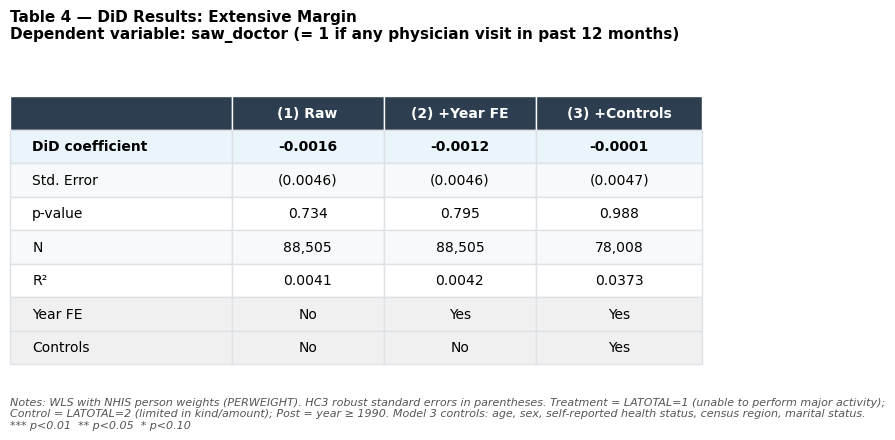

Saved → /Users/tanishagauns/Desktop/Capstone Project/Nhis/table4_extensive_margin.png


In [2]:
m1, m2, m3 = run_three('saw_doctor', df)
models = [m1, m2, m3]
k = 'did'

rows = [
    ['DiD coefficient'] + [f"{m.params[k]:+.4f}{stars(m.pvalues[k])}" for m in models],
    ['Std. Error']      + [f"({m.bse[k]:.4f})" for m in models],
    ['p-value']         + [f"{m.pvalues[k]:.3f}" for m in models],
    ['N']               + [f"{int(m.nobs):,}" for m in models],
    ['R²']              + [f"{m.rsquared:.4f}" for m in models],
    ['Year FE']         + ['No', 'Yes', 'Yes'],
    ['Controls']        + ['No', 'No', 'Yes'],
]

col_labels = ['', '(1) Raw', '(2) +Year FE', '(3) +Controls']
col_widths  = [0.32, 0.22, 0.22, 0.24]

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
ax.axis('off')

tbl = ax.table(cellText=rows, colLabels=col_labels,
               colWidths=col_widths, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.9)

# Header
for j in range(4):
    tbl[0,j].set_facecolor('#2c3e50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
    tbl[0,j].set_edgecolor('white')

# DiD row highlight
did_row, se_row = 1, 2
divider_rows = [6, 7]  # Year FE, Controls
for i in range(1, len(rows)+1):
    bg = '#eaf4fb' if i == did_row else ('#f8f9fa' if i % 2 == 0 else 'white')
    if i in divider_rows: bg = '#f0f0f0'
    for j in range(4):
        tbl[i,j].set_facecolor(bg)
        tbl[i,j].set_edgecolor('#dee2e6')
    tbl[i,0].set_text_props(ha='left', fontweight='bold' if i == did_row else 'normal')
    if i == did_row:
        for j in range(1,4): tbl[i,j].set_text_props(fontweight='bold')

ax.set_title('Table 4 — DiD Results: Extensive Margin\nDependent variable: saw_doctor (= 1 if any physician visit in past 12 months)',
             fontsize=11, fontweight='bold', loc='left', pad=6)

ax.text(0.0, -0.04,
    'Notes: WLS with NHIS person weights (PERWEIGHT). HC3 robust standard errors in parentheses. '
    'Treatment = LATOTAL=1 (unable to perform major activity);\n'
    'Control = LATOTAL=2 (limited in kind/amount); Post = year ≥ 1990. '
    'Model 3 controls: age, sex, self-reported health status, census region, marital status.\n'
    '*** p<0.01  ** p<0.05  * p<0.10',
    transform=ax.transAxes, fontsize=8, color='#555', style='italic')

plt.tight_layout()
out = OUT / 'table4_extensive_margin.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')

---
## Table 5 — DiD Results: Intensive Margin (dv12), Panels A & B

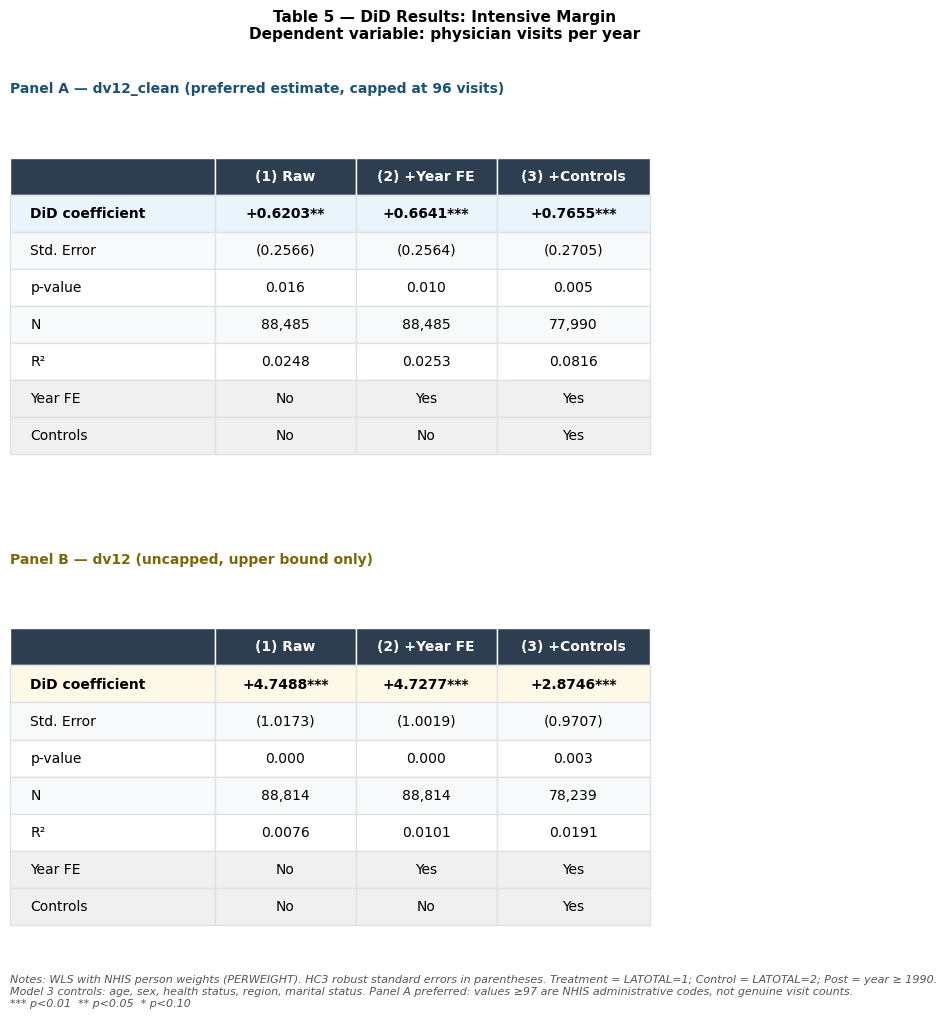

Saved → /Users/tanishagauns/Desktop/Capstone Project/Nhis/table5_intensive_margin.png


In [3]:
m1a, m2a, m3a = run_three('dv12_clean', df)
m1b, m2b, m3b = run_three('dv12', df)
k = 'did'

def make_rows(models):
    return [
        ['DiD coefficient'] + [f"{m.params[k]:+.4f}{stars(m.pvalues[k])}" for m in models],
        ['Std. Error']      + [f"({m.bse[k]:.4f})" for m in models],
        ['p-value']         + [f"{m.pvalues[k]:.3f}" for m in models],
        ['N']               + [f"{int(m.nobs):,}" for m in models],
        ['R²']              + [f"{m.rsquared:.4f}" for m in models],
        ['Year FE']         + ['No', 'Yes', 'Yes'],
        ['Controls']        + ['No', 'No', 'Yes'],
    ]

rows_a = make_rows([m1a, m2a, m3a])
rows_b = make_rows([m1b, m2b, m3b])

col_labels = ['', '(1) Raw', '(2) +Year FE', '(3) +Controls']
col_widths  = [0.32, 0.22, 0.22, 0.24]

fig, axes = plt.subplots(2, 1, figsize=(9, 10))
fig.patch.set_facecolor('white')
fig.suptitle('Table 5 — DiD Results: Intensive Margin\nDependent variable: physician visits per year',
             fontsize=11, fontweight='bold', y=1.01)

panel_info = [
    (axes[0], rows_a, 'Panel A — dv12_clean (preferred estimate, capped at 96 visits)', '#eaf4fb', '#1a5276'),
    (axes[1], rows_b, 'Panel B — dv12 (uncapped, upper bound only)',                   '#fef9e7', '#7d6608'),
]

for ax, rows, panel_title, did_color, title_color in panel_info:
    ax.axis('off')
    tbl = ax.table(cellText=rows, colLabels=col_labels,
                   colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.9)

    for j in range(4):
        tbl[0,j].set_facecolor('#2c3e50')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
        tbl[0,j].set_edgecolor('white')

    for i in range(1, len(rows)+1):
        bg = did_color if i == 1 else ('#f8f9fa' if i % 2 == 0 else 'white')
        if i in [6, 7]: bg = '#f0f0f0'
        for j in range(4):
            tbl[i,j].set_facecolor(bg)
            tbl[i,j].set_edgecolor('#dee2e6')
        tbl[i,0].set_text_props(ha='left', fontweight='bold' if i == 1 else 'normal')
        if i == 1:
            for j in range(1,4): tbl[i,j].set_text_props(fontweight='bold')

    ax.set_title(panel_title, fontsize=10, fontweight='bold',
                 loc='left', color=title_color, pad=6)

axes[1].text(0.0, -0.06,
    'Notes: WLS with NHIS person weights (PERWEIGHT). HC3 robust standard errors in parentheses. '
    'Treatment = LATOTAL=1; Control = LATOTAL=2; Post = year ≥ 1990.\n'
    'Model 3 controls: age, sex, health status, region, marital status. '
    'Panel A preferred: values ≥97 are NHIS administrative codes, not genuine visit counts.\n'
    '*** p<0.01  ** p<0.05  * p<0.10',
    transform=axes[1].transAxes, fontsize=8, color='#555', style='italic')

plt.tight_layout(h_pad=3)
out = OUT / 'table5_intensive_margin.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')

---
## Figure 7 — 2×2 DiD Decomposition

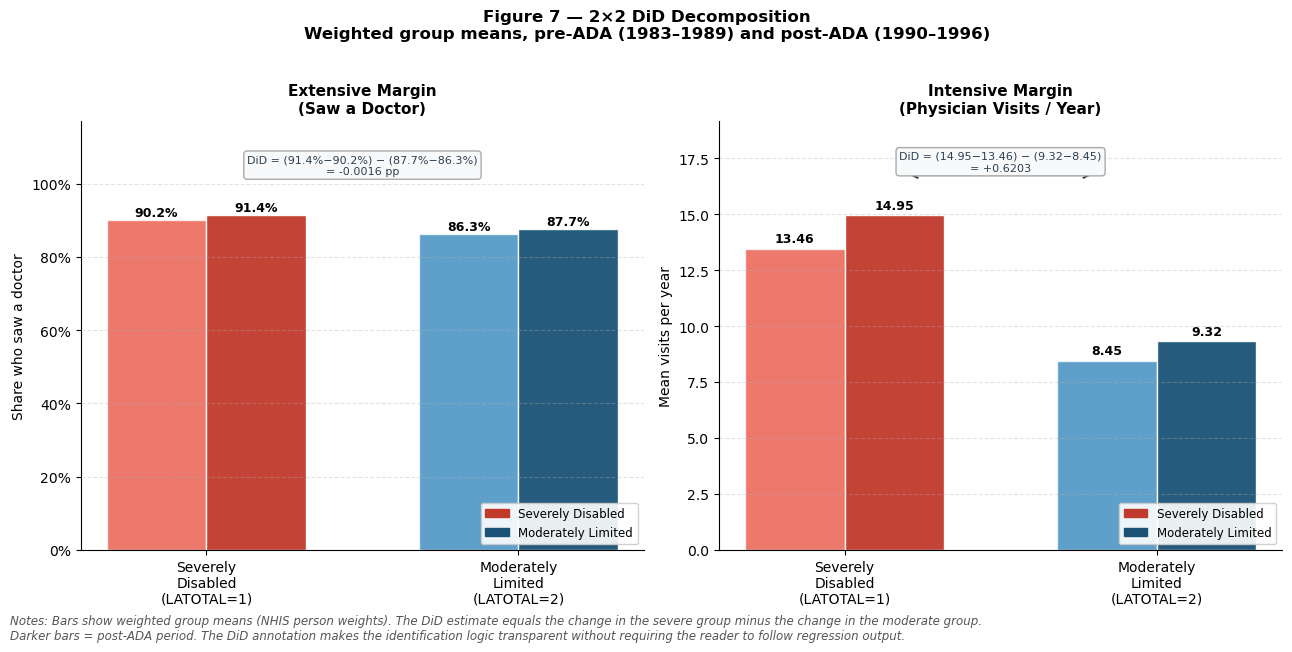

Saved → /Users/tanishagauns/Desktop/Capstone Project/Nhis/figure7_2x2_decomposition.png


In [4]:
def wmean(data, outcome, grp, yr_range):
    sub = data[(data['disabled']==grp) & (data['year'].between(*yr_range))]
    sub = sub.dropna(subset=[outcome,'perweight'])
    return np.average(sub[outcome], weights=sub['perweight'])

outcomes = {
    'saw_doctor' : ('Extensive Margin\n(Saw a Doctor)', 'Share who saw a doctor',
                    mticker.PercentFormatter(xmax=1, decimals=0)),
    'dv12_clean' : ('Intensive Margin\n(Physician Visits / Year)', 'Mean visits per year', None),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('white')

bar_w = 0.32
x     = np.array([0, 1])

for ax, (outcome, (title, ylabel, yfmt)) in zip(axes, outcomes.items()):
    ax.set_facecolor('white')

    sev_pre  = wmean(df, outcome, 1.0, (1983,1989))
    sev_post = wmean(df, outcome, 1.0, (1990,1996))
    mod_pre  = wmean(df, outcome, 0.0, (1983,1989))
    mod_post = wmean(df, outcome, 0.0, (1990,1996))

    did = (sev_post - sev_pre) - (mod_post - mod_pre)

    pre_vals  = [sev_pre,  mod_pre]
    post_vals = [sev_post, mod_post]

    bars_pre  = ax.bar(x - bar_w/2, pre_vals,  bar_w, label='Pre-ADA (1983–1989)',
                       color=['#e74c3c','#2980b9'], alpha=0.75, edgecolor='white')
    bars_post = ax.bar(x + bar_w/2, post_vals, bar_w, label='Post-ADA (1990–1996)',
                       color=['#c0392b','#1a5276'], alpha=0.95, edgecolor='white')

    # Value labels
    fmt = '{:.1%}' if outcome == 'saw_doctor' else '{:.2f}'
    for bar in list(bars_pre) + list(bars_post):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.002 if outcome=='saw_doctor' else 0.15),
                fmt.format(bar.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    # DiD annotation brace
    ymax = max(sev_post, mod_post) * (1.12 if outcome=='saw_doctor' else 1.12)
    sign = '+' if did >= 0 else ''
    did_str = f'{sign}{did:.4f}' if outcome!='saw_doctor' else f'{sign}{did:.4f} pp'
    ax.annotate('', xy=(x[0]+bar_w/2+0.04, ymax), xytext=(x[1]-bar_w/2-0.04, ymax),
                arrowprops=dict(arrowstyle='<->', color='#2c3e50', lw=1.5))
    ax.text(0.5, ymax + (0.003 if outcome=='saw_doctor' else 0.2),
            f'DiD = ({fmt.format(sev_post)}−{fmt.format(sev_pre)}) − ({fmt.format(mod_post)}−{fmt.format(mod_pre)})\n= {did_str}',
            ha='center', fontsize=8, color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f9fa', edgecolor='#aaa'))

    ax.set_xticks(x)
    ax.set_xticklabels(['Severely\nDisabled\n(LATOTAL=1)', 'Moderately\nLimited\n(LATOTAL=2)'],
                       fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    if yfmt: ax.yaxis.set_major_formatter(yfmt)
    ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top','right']].set_visible(False)
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], ylim[1]*1.22)

    # Colour legend patches
    sev_patch = mpatches.Patch(color='#c0392b', label='Severely Disabled')
    mod_patch = mpatches.Patch(color='#1a5276', label='Moderately Limited')
    pre_hatch = mpatches.Patch(facecolor='white', edgecolor='grey', hatch='//', label='Pre-ADA')
    ax.legend(handles=[sev_patch, mod_patch], fontsize=8.5,
              loc='lower right', framealpha=0.9)

fig.suptitle('Figure 7 — 2×2 DiD Decomposition\nWeighted group means, pre-ADA (1983–1989) and post-ADA (1990–1996)',
             fontsize=12, fontweight='bold', y=1.02)
fig.text(0.01, -0.03,
    'Notes: Bars show weighted group means (NHIS person weights). '
    'The DiD estimate equals the change in the severe group minus the change in the moderate group.\n'
    'Darker bars = post-ADA period. The DiD annotation makes the identification logic transparent without '
    'requiring the reader to follow regression output.',
    fontsize=8.5, color='#555', style='italic')

plt.tight_layout()
out = OUT / 'figure7_2x2_decomposition.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')

---
## Table 6 — Robustness Checks Summary

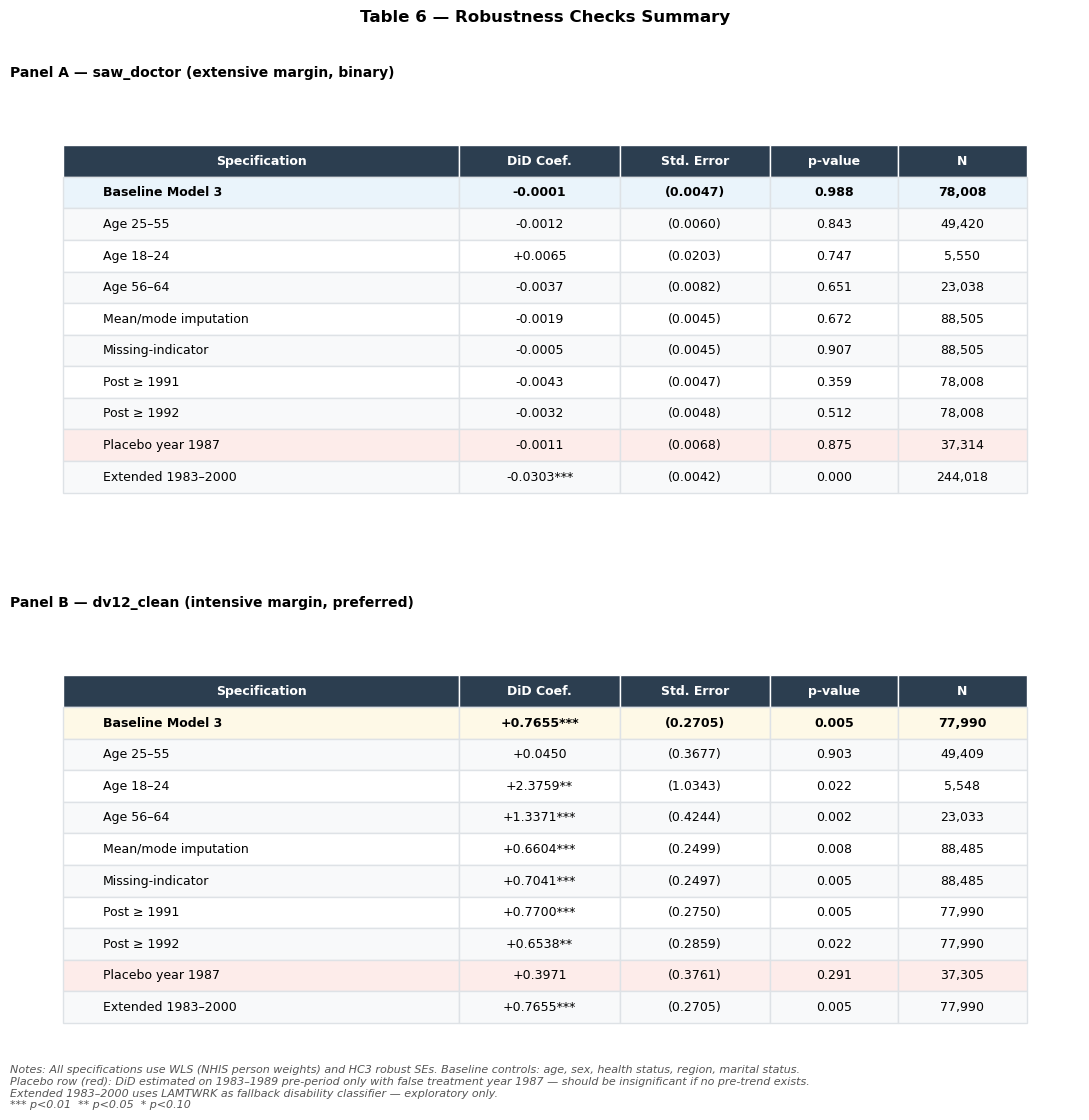

Saved → /Users/tanishagauns/Desktop/Capstone Project/Nhis/table6_robustness.png


In [5]:
# ── Run all robustness specs ──────────────────────────────────────────────────
specs = {}

# Baseline
for oc in ['saw_doctor','dv12_clean']:
    specs[('Baseline Model 3', oc)] = rob_m3(oc, df)

# Age subgroups
for lo, hi, label in [(25,55,'Age 25–55'),(18,24,'Age 18–24'),(56,64,'Age 56–64')]:
    sub = df[df['age'].between(lo, hi)]
    for oc in ['saw_doctor','dv12_clean']:
        specs[(label, oc)] = rob_m3(oc, sub)

# Mean/mode imputation
df_imp = df.copy()
for c in CONTROLS:
    if c in df_imp.columns:
        df_imp[c] = df_imp[c].fillna(df_imp[c].mode()[0])
for oc in ['saw_doctor','dv12_clean']:
    specs[('Mean/mode imputation', oc)] = rob_m3(oc, df_imp)

# Missing-indicator
df_ind = df.copy()
extra_cols = []
for c in CONTROLS:
    if c in df_ind.columns and df_ind[c].isna().sum() > 0:
        col = c + '_miss'
        df_ind[col] = df_ind[c].isna().astype(int)
        df_ind[c]   = df_ind[c].fillna(df_ind[c].mode()[0])
        extra_cols.append(col)
CONTROLS_IND = CONTROLS + extra_cols

for oc in ['saw_doctor','dv12_clean']:
    s = df_ind[df_ind[oc].notna() & df_ind['disabled'].notna() & df_ind['perweight'].notna()].copy()
    good = [c for c in CONTROLS_IND if c in s.columns and s[c].notna().mean() > 0.5]
    ctrl = ' + '.join([f'C({c})' if s[c].nunique() < 10 else c for c in good])
    s['post'] = (s['year'] >= 1990).astype(int)
    s['did']  = s['disabled'].astype(int) * s['post']
    s['year_c'] = pd.Categorical(s['year'])
    m = smf.wls(f'{oc} ~ disabled + C(year_c) + did + {ctrl}',
                data=s, weights=s['perweight']).fit(cov_type='HC3')
    specs[('Missing-indicator', oc)] = {'b': m.params['did'], 'se': m.bse['did'],
                                         'p': m.pvalues['did'], 'n': int(m.nobs)}

# Timing variants
for post_yr, label in [(1991,'Post ≥ 1991'),(1992,'Post ≥ 1992')]:
    for oc in ['saw_doctor','dv12_clean']:
        specs[(label, oc)] = rob_m3(oc, df, post_yr)

# Placebo 1987 (pre-period only)
df_pre = df[df['year'] <= 1989].copy()
for oc in ['saw_doctor','dv12_clean']:
    specs[('Placebo year 1987', oc)] = rob_m3(oc, df_pre, post_yr=1987)

# Extended sample 1983-2000
df_ext = pd.read_csv(DATA, low_memory=False)
df_ext = df_ext[(df_ext['year'].between(1983,2000)) & (df_ext['disabled'].isin([0.0,1.0]))].copy()
df_ext['dv12_clean'] = df_ext['dv12'].where(~df_ext['dv12'].isin([97,98,99,997,998,999])).clip(upper=96)
df_ext['year'] = df_ext['year'].astype(int)
for oc in ['saw_doctor','dv12_clean']:
    specs[('Extended 1983–2000', oc)] = rob_m3(oc, df_ext)

spec_order = ['Baseline Model 3','Age 25–55','Age 18–24','Age 56–64',
              'Mean/mode imputation','Missing-indicator',
              'Post ≥ 1991','Post ≥ 1992','Placebo year 1987','Extended 1983–2000']

# ── Draw table ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 11))
fig.patch.set_facecolor('white')
fig.suptitle('Table 6 — Robustness Checks Summary', fontsize=12, fontweight='bold', y=1.01)

panel_outcomes = [('Panel A — saw_doctor (extensive margin, binary)', 'saw_doctor', '#eaf4fb'),
                  ('Panel B — dv12_clean (intensive margin, preferred)', 'dv12_clean', '#fef9e7')]

for ax, (panel_title, oc, row_color) in zip(axes, panel_outcomes):
    ax.axis('off')
    rows = []
    for sp in spec_order:
        r = specs.get((sp, oc), {})
        b = r.get('b', np.nan)
        se = r.get('se', np.nan)
        p  = r.get('p', np.nan)
        n  = r.get('n', 0)
        b_str  = f"{b:+.4f}{stars(p)}" if not np.isnan(b) else '—'
        se_str = f"({se:.4f})" if not np.isnan(se) else ''
        p_str  = f"{p:.3f}" if not np.isnan(p) else '—'
        n_str  = f"{n:,}" if n > 0 else '—'
        rows.append([sp, b_str, se_str, p_str, n_str])

    col_labels = ['Specification', 'DiD Coef.', 'Std. Error', 'p-value', 'N']
    col_widths  = [0.37, 0.15, 0.14, 0.12, 0.12]

    tbl = ax.table(cellText=rows, colLabels=col_labels,
                   colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.55)

    for j in range(5):
        tbl[0,j].set_facecolor('#2c3e50')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
        tbl[0,j].set_edgecolor('white')

    for i, sp in enumerate(spec_order, start=1):
        r = specs.get((sp, oc), {})
        p = r.get('p', 1.0)
        bg = row_color if sp == 'Baseline Model 3' else (
             '#fdecea' if sp == 'Placebo year 1987' else
             ('#f8f9fa' if i % 2 == 0 else 'white'))
        for j in range(5):
            tbl[i,j].set_facecolor(bg)
            tbl[i,j].set_edgecolor('#dee2e6')
        tbl[i,0].set_text_props(ha='left',
                                 fontweight='bold' if sp == 'Baseline Model 3' else 'normal')
        if sp == 'Baseline Model 3':
            for j in range(1,5): tbl[i,j].set_text_props(fontweight='bold')

    ax.set_title(panel_title, fontsize=10, fontweight='bold', loc='left', pad=5)

axes[1].text(0.0, -0.05,
    'Notes: All specifications use WLS (NHIS person weights) and HC3 robust SEs. '
    'Baseline controls: age, sex, health status, region, marital status.\n'
    'Placebo row (red): DiD estimated on 1983–1989 pre-period only with false treatment year 1987 — '
    'should be insignificant if no pre-trend exists.\n'
    'Extended 1983–2000 uses LAMTWRK as fallback disability classifier — exploratory only.\n'
    '*** p<0.01  ** p<0.05  * p<0.10',
    transform=axes[1].transAxes, fontsize=8, color='#555', style='italic')

plt.tight_layout(h_pad=3)
out = OUT / 'table6_robustness.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')

---
## Figure 8 — Robustness Forest Plot

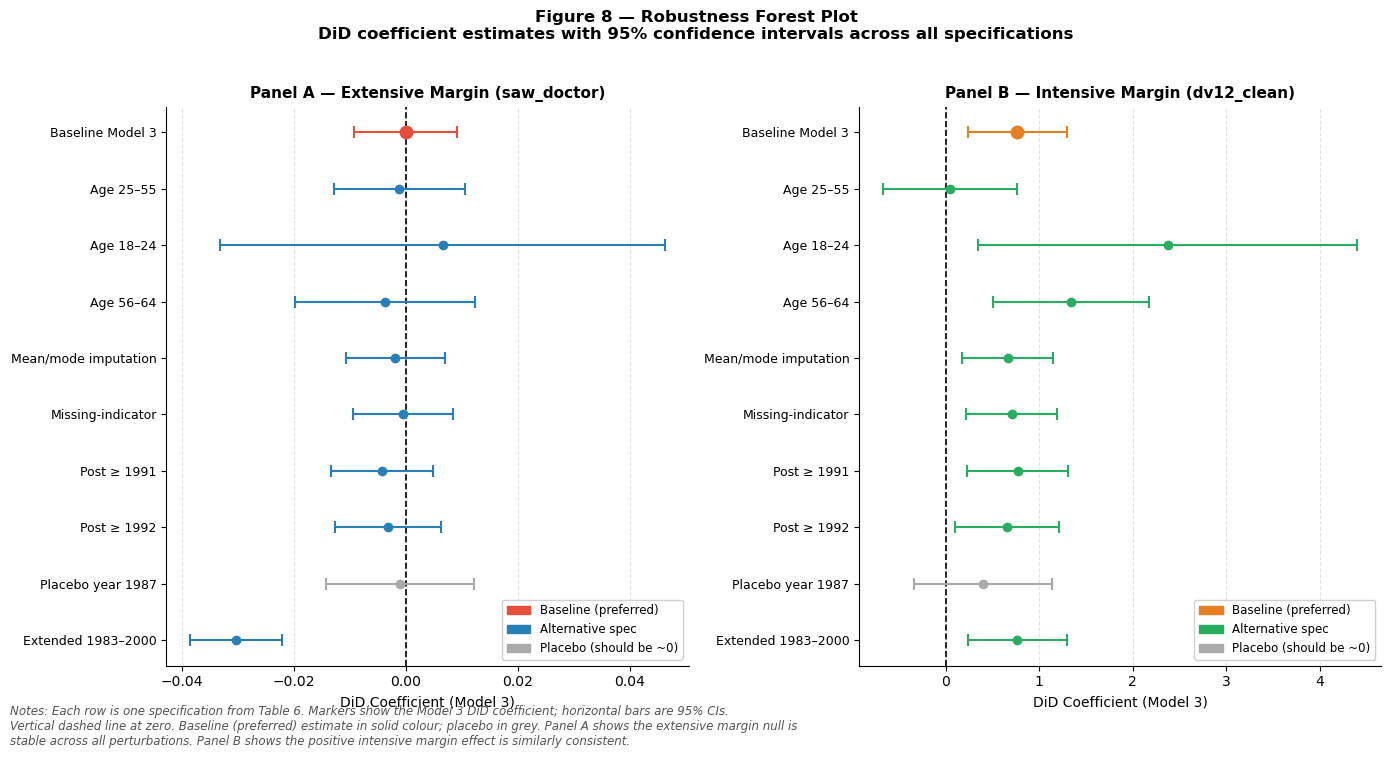

Saved → /Users/tanishagauns/Desktop/Capstone Project/Nhis/figure8_forest_plot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white')

panel_outcomes = [
    (axes[0], 'saw_doctor', 'Panel A — Extensive Margin (saw_doctor)', '#e74c3c', '#2980b9'),
    (axes[1], 'dv12_clean', 'Panel B — Intensive Margin (dv12_clean)', '#e67e22', '#27ae60'),
]

for ax, oc, title, base_color, other_color in panel_outcomes:
    ax.set_facecolor('white')

    coefs, ses, labels, colors = [], [], [], []
    for sp in reversed(spec_order):
        r = specs.get((sp, oc), {})
        b  = r.get('b', np.nan)
        se = r.get('se', np.nan)
        if np.isnan(b): continue
        coefs.append(b)
        ses.append(se)
        labels.append(sp)
        colors.append(base_color if sp == 'Baseline Model 3' else
                      '#aaaaaa' if sp == 'Placebo year 1987' else other_color)

    y = np.arange(len(coefs))
    ci95 = [1.96 * se for se in ses]

    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', zorder=2)

    for i, (c, ci, col, lbl) in enumerate(zip(coefs, ci95, colors, labels)):
        zorder = 5 if lbl == 'Baseline Model 3' else 4
        ms = 9 if lbl == 'Baseline Model 3' else 6
        ax.errorbar(c, i, xerr=ci, fmt='o', color=col,
                    ecolor=col, elinewidth=1.5, capsize=4, capthick=1.5,
                    markersize=ms, zorder=zorder)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('DiD Coefficient (Model 3)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.spines[['top','right']].set_visible(False)

    # Legend
    base_patch  = mpatches.Patch(color=base_color,  label='Baseline (preferred)')
    other_patch = mpatches.Patch(color=other_color, label='Alternative spec')
    placebo_patch = mpatches.Patch(color='#aaaaaa', label='Placebo (should be ~0)')
    ax.legend(handles=[base_patch, other_patch, placebo_patch],
              fontsize=8.5, loc='lower right', framealpha=0.9)

fig.suptitle('Figure 8 — Robustness Forest Plot\n'
             'DiD coefficient estimates with 95% confidence intervals across all specifications',
             fontsize=12, fontweight='bold', y=1.02)
fig.text(0.01, -0.03,
    'Notes: Each row is one specification from Table 6. '
    'Markers show the Model 3 DiD coefficient; horizontal bars are 95% CIs.\n'
    'Vertical dashed line at zero. Baseline (preferred) estimate in solid colour; '
    'placebo in grey. Panel A shows the extensive margin null is\n'
    'stable across all perturbations. Panel B shows the positive intensive margin '
    'effect is similarly consistent.',
    fontsize=8.5, color='#555', style='italic')

plt.tight_layout()
out = OUT / 'figure8_forest_plot.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')

---
## Table 7 — Descriptive Cross-Sections: Unidentified Outcomes

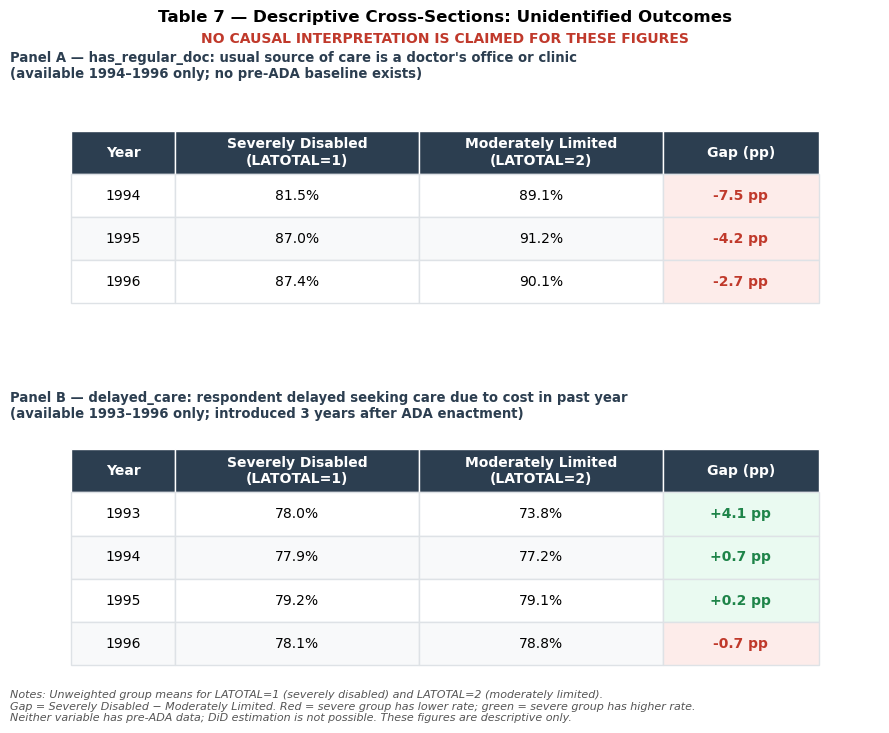

Saved → /Users/tanishagauns/Desktop/Capstone Project/Nhis/table7_descriptive_crosssections.png


In [7]:
# has_regular_doc: 1994-1996 from analysis sample (LATOTAL 1 vs 2)
hrd_rows = []
for yr in [1994, 1995, 1996]:
    yr_df = df[df['year'] == yr]
    sev = yr_df[yr_df['disabled']==1.0]['has_regular_doc'].dropna().mean()*100
    mod = yr_df[yr_df['disabled']==0.0]['has_regular_doc'].dropna().mean()*100
    gap = sev - mod
    hrd_rows.append([str(yr), f'{sev:.1f}%', f'{mod:.1f}%', f'{gap:+.1f} pp'])

# delayed_care: 1993-1996 from analysis sample
dc_rows = []
for yr in [1993, 1994, 1995, 1996]:
    yr_df = df[df['year'] == yr]
    sev = yr_df[yr_df['disabled']==1.0]['delayed_care'].dropna().mean()*100
    mod = yr_df[yr_df['disabled']==0.0]['delayed_care'].dropna().mean()*100
    gap = sev - mod
    dc_rows.append([str(yr), f'{sev:.1f}%', f'{mod:.1f}%', f'{gap:+.1f} pp'])

col_labels = ['Year', 'Severely Disabled\n(LATOTAL=1)', 'Moderately Limited\n(LATOTAL=2)', 'Gap (pp)']
col_widths  = [0.12, 0.28, 0.28, 0.18]

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
fig.patch.set_facecolor('white')

fig.text(0.5, 1.02,
    'Table 7 — Descriptive Cross-Sections: Unidentified Outcomes',
    ha='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.99,
    'NO CAUSAL INTERPRETATION IS CLAIMED FOR THESE FIGURES',
    ha='center', fontsize=10, fontweight='bold', color='#c0392b')

panel_info = [
    (axes[0], hrd_rows,
     'Panel A — has_regular_doc: usual source of care is a doctor\'s office or clinic\n'
     '(available 1994–1996 only; no pre-ADA baseline exists)',
     '#eaf4fb'),
    (axes[1], dc_rows,
     'Panel B — delayed_care: respondent delayed seeking care due to cost in past year\n'
     '(available 1993–1996 only; introduced 3 years after ADA enactment)',
     '#fef9e7'),
]

for ax, rows, panel_title, row_color in panel_info:
    ax.axis('off')

    tbl = ax.table(cellText=rows, colLabels=col_labels,
                   colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 2.4)

    for j in range(4):
        tbl[0,j].set_facecolor('#2c3e50')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
        tbl[0,j].set_edgecolor('white')

    for i, row in enumerate(rows, start=1):
        gap_val = float(row[3].replace(' pp','').replace('+',''))
        for j in range(4):
            tbl[i,j].set_facecolor('#f8f9fa' if i%2==0 else 'white')
            tbl[i,j].set_edgecolor('#dee2e6')
        # Colour the gap column
        gap_color = '#fdecea' if gap_val < 0 else '#eafaf1'
        tbl[i,3].set_facecolor(gap_color)
        tbl[i,3].set_text_props(
            color='#c0392b' if gap_val < 0 else '#1e8449', fontweight='bold')

    ax.set_title(panel_title, fontsize=9.5, fontweight='bold', loc='left',
                 color='#2c3e50', pad=5)

axes[1].text(0.0, -0.12,
    'Notes: Unweighted group means for LATOTAL=1 (severely disabled) and LATOTAL=2 (moderately limited).\n'
    'Gap = Severely Disabled − Moderately Limited. '
    'Red = severe group has lower rate; green = severe group has higher rate.\n'
    'Neither variable has pre-ADA data; DiD estimation is not possible. '
    'These figures are descriptive only.',
    transform=axes[1].transAxes, fontsize=8, color='#555', style='italic')

plt.tight_layout(h_pad=3)
out = OUT / 'table7_descriptive_crosssections.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {out}')

---
## Export summary

In [8]:
outputs = [
    'table4_extensive_margin.png',
    'table5_intensive_margin.png',
    'figure7_2x2_decomposition.png',
    'table6_robustness.png',
    'figure8_forest_plot.png',
    'table7_descriptive_crosssections.png',
]
print('Output files:')
for f in outputs:
    p = OUT / f
    size = f'{p.stat().st_size/1024:.0f} KB' if p.exists() else 'MISSING'
    print(f'  {"✓" if p.exists() else "✗"}  {f}  ({size})')

Output files:
  ✓  table4_extensive_margin.png  (126 KB)
  ✓  table5_intensive_margin.png  (202 KB)
  ✓  figure7_2x2_decomposition.png  (207 KB)
  ✓  table6_robustness.png  (351 KB)
  ✓  figure8_forest_plot.png  (210 KB)
  ✓  table7_descriptive_crosssections.png  (218 KB)
